In [1]:
'''
Code for testing a mixer module, to have an HDL implementation
'''

import numpy as np
import scipy
import matplotlib.pyplot as plt

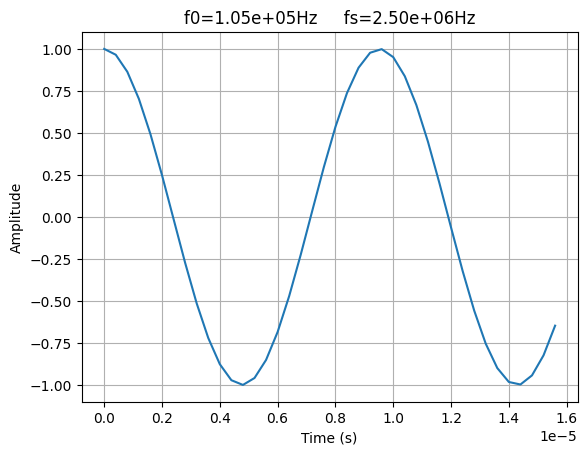

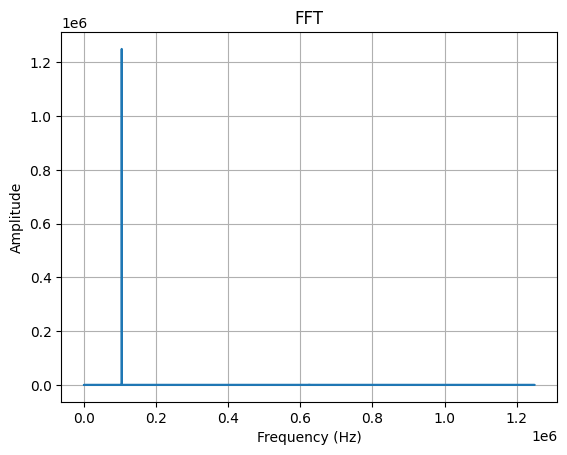

In [2]:
fs = 2_500_000       # Sample rate: 2.5 MHz
duration = 1      # 1 second
f0 = 105_000          # Signal frequency: 100 kHz
flo = 100_000        # Local oscilator for mixing
amplitude = 1.0
phase = 0.0

t = np.arange(0, duration, 1 / fs)

x = amplitude * np.cos(2 * np.pi * f0 * t + phase) # Input signal

I_arr = np.cos(2 * np.pi * flo * t) # I component of local oscilator
Q_arr = np.sin(2 * np.pi * flo * t) # Q component of local oscilator

# Plotting the singal before it's mixed

plt.plot(t[:40], x[:40])
plt.title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Plot FFT of the signal

X = np.fft.rfft(x)
freq = np.fft.rfftfreq(int(duration * fs), d=1/fs)

X_shifted = np.fft.fftshift(X)
freq_shifted = np.fft.fftshift(freq)

plt.plot(freq_shifted, np.abs(X_shifted))
plt.title("FFT")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

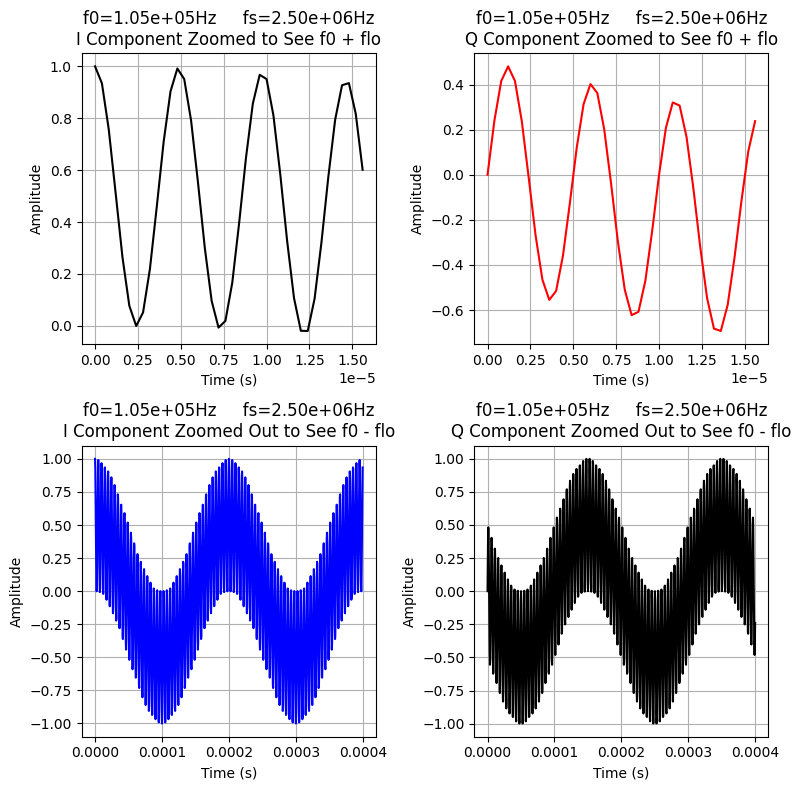

In [3]:
# Multiply the input by the local osciallator and observe the effects

I_x = I_arr * x
Q_x = Q_arr * x

# Plot the two signals

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8,8))

axs[0,0].plot(t[:40], I_x[:40], color='k')
axs[0,0].set_xlabel("Time (s)")
axs[0,0].set_ylabel("Amplitude")
axs[0,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component Zoomed to See f0 + flo")
axs[0,0].grid()

axs[0,1].plot(t[:40], Q_x[:40], color='r')
axs[0,1].set_xlabel("Time (s)")
axs[0,1].set_ylabel("Amplitude")
axs[0,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component Zoomed to See f0 + flo")
axs[0,1].grid()

axs[1,0].plot(t[:1000], I_x[:1000], color='b')
axs[1,0].set_xlabel("Time (s)")
axs[1,0].set_ylabel("Amplitude")
axs[1,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component Zoomed Out to See f0 - flo")
axs[1,0].grid()

axs[1,1].plot(t[:1000], Q_x[:1000], color='k')
axs[1,1].set_xlabel("Time (s)")
axs[1,1].set_ylabel("Amplitude")
axs[1,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component Zoomed Out to See f0 - flo")
axs[1,1].grid()
plt.tight_layout()
plt.show()

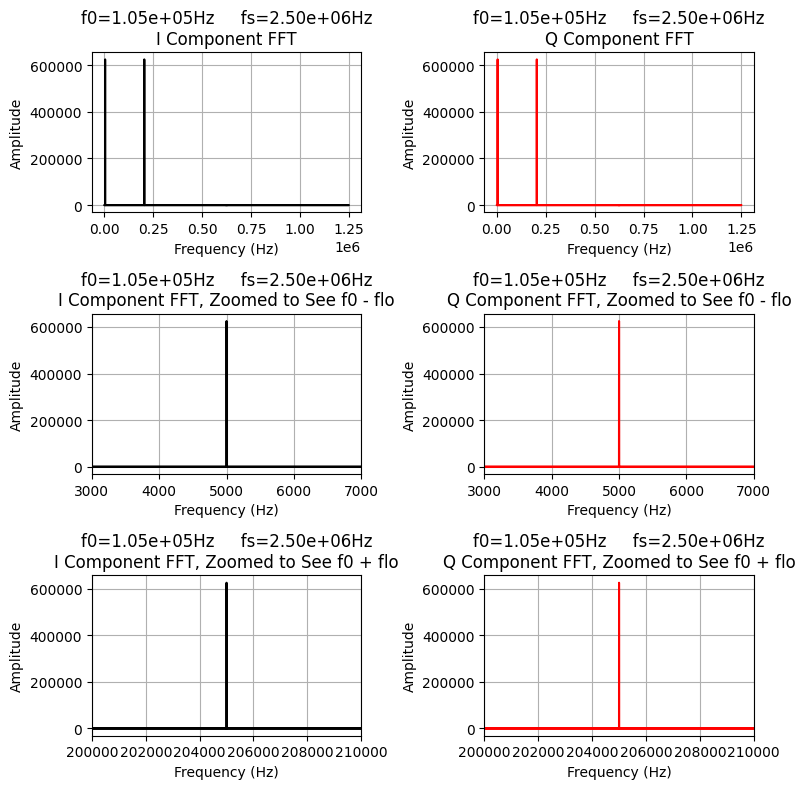

In [4]:
# Plot FFT's

I_X = np.fft.rfft(I_x)
I_X_shifted = np.fft.fftshift(I_X)
Q_X = np.fft.rfft(Q_x)
Q_X_shifted = np.fft.fftshift(Q_X)

freq = np.fft.rfftfreq(int(duration * fs), d=1/fs)
freq_shifted = np.fft.fftshift(freq)

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8,8))

axs[0,0].plot(freq_shifted, abs(I_X_shifted), color='k')
axs[0,0].set_xlabel("Frequency (Hz)")
axs[0,0].set_ylabel("Amplitude")
axs[0,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component FFT")
axs[0,0].grid()

axs[0,1].plot(freq_shifted, abs(Q_X_shifted), color='r')
axs[0,1].set_xlabel("Frequency (Hz)")
axs[0,1].set_ylabel("Amplitude")
axs[0,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component FFT")
axs[0,1].grid()

axs[1,0].plot(freq_shifted, abs(I_X_shifted), color='k')
axs[1,0].set_xlim(3_000, 7_000)
axs[1,0].set_xlabel("Frequency (Hz)")
axs[1,0].set_ylabel("Amplitude")
axs[1,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component FFT, Zoomed to See f0 - flo")
axs[1,0].grid()

axs[1,1].plot(freq_shifted, abs(Q_X_shifted), color='r')
axs[1,1].set_xlim(3_000, 7_000)
axs[1,1].set_xlabel("Frequency (Hz)")
axs[1,1].set_ylabel("Amplitude")
axs[1,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component FFT, Zoomed to See f0 - flo")
axs[1,1].grid()

axs[2,0].plot(freq_shifted, abs(I_X_shifted), color='k')
axs[2,0].set_xlim(200_000, 210_000)
axs[2,0].set_xlabel("Frequency (Hz)")
axs[2,0].set_ylabel("Amplitude")
axs[2,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component FFT, Zoomed to See f0 + flo")
axs[2,0].grid()

axs[2,1].plot(freq_shifted, abs(Q_X_shifted), color='r')
axs[2,1].set_xlim(200_000, 210_000)
axs[2,1].set_xlabel("Frequency (Hz)")
axs[2,1].set_ylabel("Amplitude")
axs[2,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component FFT, Zoomed to See f0 + flo")
axs[2,1].grid()

plt.tight_layout()
plt.show()

In [5]:
def CIC(data: np.array, in_bit: int, out_bit: int, N: int, R: int, M: int = 1, full_prec : bool = True):
    '''Important Notes:
            -Parameters: 
                -N is the number of integrator and comb stages
                -R is the decimation ratio (aka. pick every R sample).
                -M remains unused currently (may be implemented)
            -Function has a slow_clk and clk, clk repersents system clock (MHz range),
            slow_clk repersents downsampled clock.
            -...recu variables refer to recursive elements in the filter. I.e. y[n-1], x[n-1]
            for intgrator and comb respectively
            -Added redudant variables for readability and symmetry, I.e. comb_module_out. These could be removed
            for efficiency
            -Shift parameter added to toggle the bitshift due to high gain. Likely need to rethink this

            Created this function while working with LASSO
    '''
    
    if not full_prec:
        data_type = np.int64
    else:
        data_type = np.float64
    
    '''-------Useful Constants------'''
    signal_len = data.size
    output_signal_len = int(np.ceil(signal_len / R))
    
    out_rate = int(np.log2(R))
    B_growth = int(np.ceil(N * np.log2(R * M)))
    gain = (R*M)**N
    
    '''----Register Declerations----'''
    integrator_module_in = data
    
    integrator_in = np.zeros(N, dtype = data_type) 
    integrator_out = np.zeros(N, dtype = data_type)
    integrator_out_recu = np.zeros(N, dtype = data_type)
    
    integrator_module_out = 0
    
    comb_module_in = 0
    
    comb_in = np.zeros(N, dtype = data_type)
    comb_out = np.zeros(N, dtype = data_type)
    comb_in_recu = np.zeros(N, dtype = data_type)
    
    comb_module_out = 0
    
    clk_slow = 0
    
    output_signal = np.zeros(output_signal_len, dtype = data_type)
    
    '''Probes'''
    integrator_out_probe = np.zeros(signal_len)
    
    '''---------Main Loop--------'''
    for clk in range(signal_len):
        
        '''Integrator Module'''
        for i in range(N):
            if(i == 0):
                integrator_in[i] = integrator_module_in[clk]
            else:
                integrator_in[i] = integrator_out[i - 1]
    
            integrator_out[i] = integrator_in[i] + integrator_out_recu[i]
            
            if not full_prec:
                integrator_out[i] = two_comp_wrap(integrator_out[i], in_bit + N*out_rate)
                
            integrator_out_recu[i] = integrator_out[i]
        
        if not full_prec:
            shift = max(0, (in_bit + N * out_rate) - out_bit)
            integrator_module_out = integrator_out[-1] >> shift
        else:
            integrator_module_out = integrator_out[-1]
        
        integrator_out_probe[clk] = integrator_out[-1]
        
        '''Comb Module'''
        if(clk % R == 0):
            for i in range(N):
                if(i == 0):
                    comb_in[i] = integrator_module_out
                else:
                    comb_in[i] = comb_out[i - 1]
                
                comb_out[i] = comb_in[i] - comb_in_recu[i]
                
                if not full_prec:
                    comb_out[i] = two_comp_wrap(comb_out[i], out_bit)
                
                comb_in_recu[i] = comb_in[i]
                
            comb_module_out = comb_out[-1]
            
            output_signal[clk_slow] = comb_module_out
            clk_slow += 1
    
    '''End Function'''
    return output_signal, integrator_out_probe

In [6]:
# Put mixed signal through a CIC decimation filter to observe the effects

R = 64 # Decimation factor
N = 2 # 2 comb and integrator implementation

I_x_decim = CIC(I_x, 12, 20, N, R, full_prec = True)[0]
Q_x_decim = CIC(Q_x, 12, 20, N, R, full_prec = True)[0]

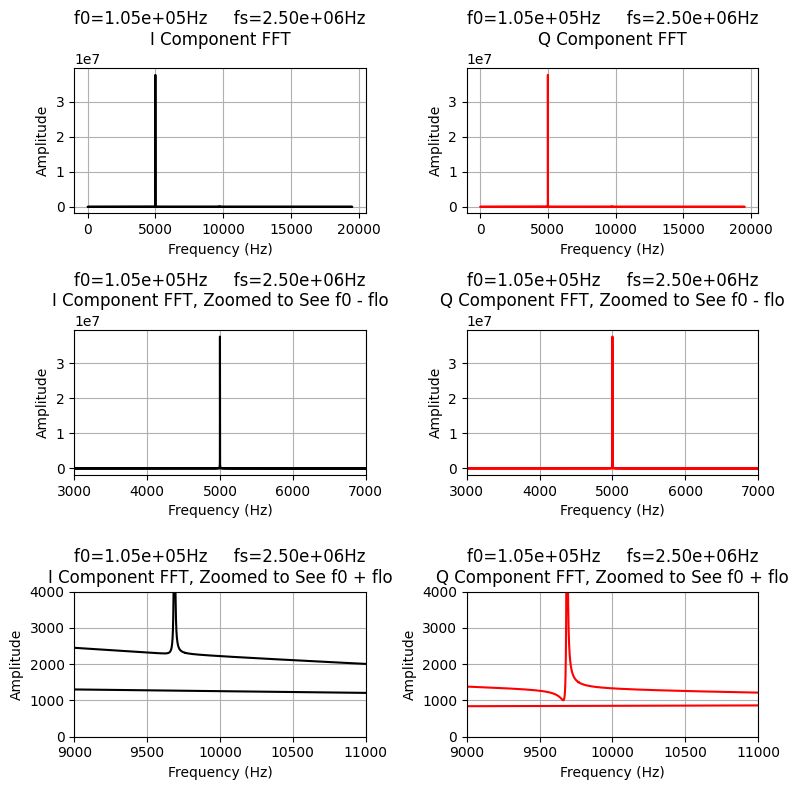

In [7]:
# Plot FFT's

I_X_decim = np.fft.rfft(I_x_decim)
I_X_shifted = np.fft.fftshift(I_X_decim)
Q_X_decim = np.fft.rfft(Q_x_decim)
Q_X_shifted = np.fft.fftshift(Q_X_decim)

freq =  np.fft.rfftfreq(len(I_x_decim), d=1 / (fs/R))
freq_shifted = np.fft.fftshift(freq)

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8,8))

axs[0,0].plot(freq_shifted, np.abs(I_X_shifted), color='k')
axs[0,0].set_xlabel("Frequency (Hz)")
axs[0,0].set_ylabel("Amplitude")
axs[0,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component FFT")
axs[0,0].grid()

axs[0,1].plot(freq_shifted, np.abs(Q_X_shifted), color='r')
axs[0,1].set_xlabel("Frequency (Hz)")
axs[0,1].set_ylabel("Amplitude")
axs[0,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component FFT")
axs[0,1].grid()

axs[1,0].plot(freq_shifted, np.abs(I_X_shifted), color='k')
axs[1,0].set_xlim(3_000, 7_000)
axs[1,0].set_xlabel("Frequency (Hz)")
axs[1,0].set_ylabel("Amplitude")
axs[1,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component FFT, Zoomed to See f0 - flo")
axs[1,0].grid()

axs[1,1].plot(freq_shifted, np.abs(Q_X_shifted), color='r')
axs[1,1].set_xlim(3_000, 7_000)
axs[1,1].set_xlabel("Frequency (Hz)")
axs[1,1].set_ylabel("Amplitude")
axs[1,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component FFT, Zoomed to See f0 - flo")
axs[1,1].grid()

axs[2,0].plot(freq_shifted, np.abs(I_X_shifted), color='k')
axs[2,0].set_xlim(9_000, 11_000)
axs[2,0].set_xlabel("Frequency (Hz)")
axs[2,0].set_ylabel("Amplitude")
axs[2,0].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nI Component FFT, Zoomed to See f0 + flo")
axs[2,0].set_ylim(0, 4000)
axs[2,0].grid()

axs[2,1].plot(freq_shifted, np.abs(Q_X_shifted), color='r')
axs[2,1].set_xlim(9_000, 11_000)
axs[2,1].set_xlabel("Frequency (Hz)")
axs[2,1].set_ylabel("Amplitude")
axs[2,1].set_title(f"f0={f0:.2e}Hz     fs={fs:.2e}Hz\nQ Component FFT, Zoomed to See f0 + flo")
axs[2,1].set_ylim(0, 4000)
axs[2,1].grid()

plt.tight_layout()
plt.show()

In [148]:
# Creating a fixed point implementation as a reference for the HDL implementation

def float_to_Q1_15(data: float) -> int:
    '''
    Takes in a floating point number and returns that numbers repersenation in Q.15 fixed point
    Args:
        data: float - number to be converted
    Returns:
        q1_15_num: int - number converted to Q1.15
    '''

    q1_15_num = round(data * (2**15))

    if q1_15_num > 32767: q1_15_num = 32767
    elif q1_15_num < -32768: q1_15_num = -32768

    return q1_15_num

def float_array_to_q1_15(data: np.ndarray) -> np.ndarray:
    '''
    Takes in an array of floating points and returns that array in Q.15 fixed point
    Args:
        data: np.ndarray - array to be converted
    Returns:
        np.ndarray of 16 bit Q1.15 fixed point numbers
    '''
    scale = 1 << 15

    quantized = np.rint(data * scale)
    quantized = np.clip(quantized, -(1 << 15), (1 << 15) - 1)

    return quantized.astype(np.int16)

def q1_15_to_float_array(data: np.ndarray) -> np.ndarray:
    scale = 1 << 15

    return data.astype(np.float64) / scale

def two_comp_wrap(data: int, width: int):
    mask = (1 << width) - 1
    
    #remove top bits above width
    data &= mask
    #checking to see if num has wrapped above limit
    if(data >= 2**(width - 1)):
        data -= 2**(width)
        
    return data

In [247]:
'''
For NCO, use that equation that tells you the frequency based on the amount of bits and phase increment you use and then just compute an array of cosine values
at the computed increments that wrap around. Then I can just multiply that with my signal array and that should be good I think?

Going to try and use a CORDIC algorothim for the cosine amplitude generation. Going to test that first here.
'''

def cordic_cos_approx_Q1_15(angle_rad, N : int):
    '''
    Function uses the CORDIC algorithim to approximate the cosine value of a given angle.
    Args : 
        angle_rad : int - The desired angle to calculate the cosine of. Expects Q1.15 format AND NORMALIZED BY PI
        N : int - The amount of iterations to use (aka the amount of CORDIC angles to compare against)
    Returns :
        cos_val : int - Calcualted cosine value, returned in Q1.15 format
    '''

    # Cordic can only range from around -100 degrees to 100 so need to limit range to a single 90 degree quadrant and later map values
    upper_rad_limit_q1_15 = float_to_Q1_15(1/2) # pi/2 upper bound
    lower_rad_limit_q1_15 = float_to_Q1_15(-1/2) #-pi/2 lower bound

    negate_cos = False

    # If angle enters the 4th or 3rd quadrant, wrap back to 1st and 2nd, then negate answer at the end
    if angle_rad > upper_rad_limit_q1_15:
       # Reflect into range and DONT negate (this bound corresponds to 4th quadrant)
       angle_rad = angle_rad - (2 * (angle_rad - upper_rad_limit_q1_15))
       negate_cos = True
    elif angle_rad < lower_rad_limit_q1_15:
       # Reflect into range and DO negate (this bound corresponds to 3rd quadrant)
       angle_rad = angle_rad - (2 * (angle_rad - lower_rad_limit_q1_15))
       negate_cos = True
    
    K = 1.64676025786 # 16 term cosine product correction term due to factoring out a cosine out of every iteration
    curr_angle_error = angle_rad # Vector starts at 0 rad so angle err = angle_rad
    x_curr = 1 / K # Starting the x value at 1/K will allow the algorithim to naturally rescale and normalize at the end
    x_curr = int(float_to_Q1_15(x_curr))
    y_curr = 0
    
    # Generate 16 angles in the sequence for testing
    cordic_angle_seq = np.asarray([np.arctan(2 ** (-i)) for i in range(0,N - 1)])

    # Normalize by pi. Doing this allows for the range -pi < 0 < pi to fit within the Q1.15 encoding cleanly 
    cordic_angle_seq_norm = cordic_angle_seq / np.pi
    # Convert to Q1.15
    cordic_angle_seq = float_array_to_q1_15(cordic_angle_seq_norm)
    
    # These are the angles that we will use to approach our true angle we are trying to calculate the sin or cos of
    for i, angle in enumerate(cordic_angle_seq):
        if(curr_angle_error > 0):
            x_curr_temp = x_curr + (y_curr >> i)
            y_curr_temp = y_curr - (x_curr >> i)
            x_curr = x_curr_temp
            y_curr = y_curr_temp
            curr_angle_error = curr_angle_error - angle
        else:
            x_curr_temp = x_curr - (y_curr >> i)
            y_curr_temp = y_curr + (x_curr >> i)
            x_curr = x_curr_temp
            y_curr = y_curr_temp
            curr_angle_error = curr_angle_error + angle

    return [x_curr if not negate_cos else x_curr * -1, y_curr] # This list contains the I and Q values

In [248]:
# Testing fixed point

angle_rad = 0
angle_rad_norm = angle_rad / np.pi #Normalize by pi
angle_rad_norm = float_to_Q1_15(angle_rad_norm)
N = 15

cosine_val = cordic_cos_approx_Q1_15(angle_rad_norm, N)

cosine_val_float = q1_15_to_float_array(np.asarray(cosine_val))

print(f"approx : {cosine_val_float}, np.cos : {np.cos(angle_rad)}, diff : {cosine_val_float - np.cos(angle_rad)}")

approx : [1.00006104e+00 6.10351562e-05], np.cos : 1.0, diff : [ 6.10351562e-05 -9.99938965e-01]


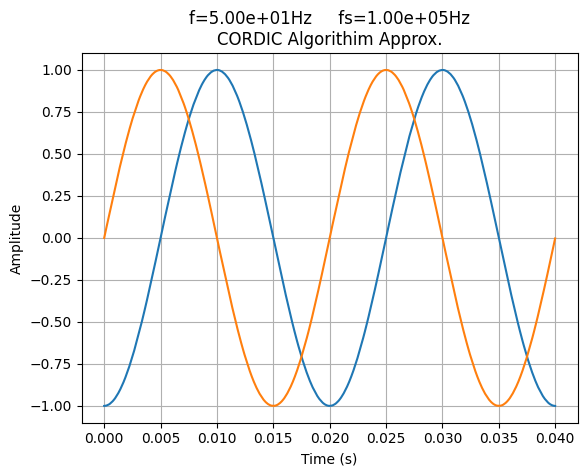

In [249]:
# Generate a cos wave to test
fs = 100_000 #100kHz
f = 50 # 100Hz
duration = 2 # 2 second sample time
N = 16 # Number of iteration of the CORDIC algorithim

time_arr = np.arange(0, duration, 1/fs)
angle_arr = 2 * np.pi * f * time_arr

# Normalize by pi
angle_arr /= np.pi

# Mod 2 to keep it periodic
angle_arr = (angle_arr) % 2

# Subtract 1 from the angle arr to keep it in range -1 < rad/pi < 1
angle_arr -= 1 # This action phase shifts the signal by 180 degrees ***** 0 -> -1 which is -pi rad

# Convert angles to Q1.15
angle_arr_q1_15 = float_array_to_q1_15(angle_arr)

# Create cosine values
cosine_q1_15 = np.asarray([cordic_cos_approx_Q1_15(i, N) for i in angle_arr_q1_15])

# Convert back to float
cosine_float = q1_15_to_float_array(cosine_q1_15)

# Plot
plt.plot(time_arr[:4000], cosine_float[:4000])
plt.title(f"f={f:.2e}Hz     fs={fs:.2e}Hz\nCORDIC Algorithim Approx.")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [250]:
'''
Going to now try and model the full NCO with angle and CORDIC cosine amplitude generation

For the phase accumulator:
    Will use the same Q1.15, normalized by pi format.
    Thus going to use a signed 16bit integer format for the accumaltor
    K ~ 2^P * f_out/f_clk
    K ~ 2^16 * f_out/f_clk

    For now, Im going to say f_out = 10MHz and f_clk = 125MHz
    K ~ 2^16 * 10/125 = 5243
    
'''

def phase_accu():
    F_CLK = 125e6 # Hz
    F_OUT = 10e6 # Hz
    ACCU_WIDTH = 16
    K = int(np.round(2 ** ACCU_WIDTH * (F_OUT/F_CLK)))

    phase_accu.accumulator += K
    phase_accu.accumulator = two_comp_wrap(phase_accu.accumulator, ACCU_WIDTH) # Simulate fixed point wrap
    return phase_accu.accumulator

phase_accu.accumulator = 0 # starting at negative k to shift the first angle back to zero

In [251]:
num_samples = int(100e3)
N = 16
F_CLK = 125e6

angle_arr = np.asarray([phase_accu() for i in range(num_samples)])
cos_values = np.asarray([cordic_cos_approx_Q1_15(i, N) for i in angle_arr])

sample_idx_array = np.arange(0, num_samples, 1)
time_arr = np.asarray([(i / F_CLK) for i in sample_idx_array])

cos_float = q1_15_to_float_array(cos_values)

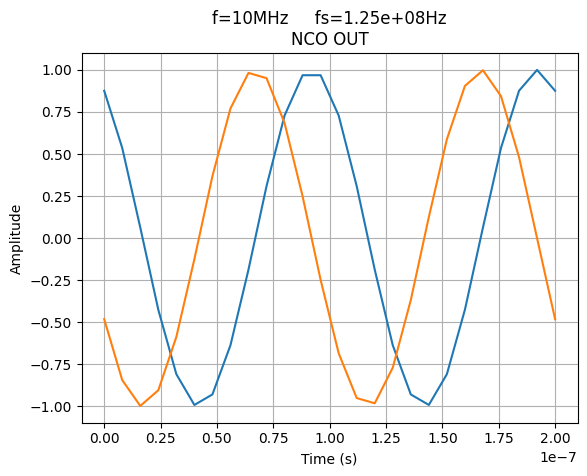

In [252]:
plt.plot(time_arr[:26], cos_float[:26])
plt.title(f"f=10MHz     fs={F_CLK:.2e}Hz\nNCO OUT")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()